# Classificação de Imagens com TensorFlow/Keras

Construir um primeiro classificador de imagens usando TensorFlow/Keras.

O objetivo é entender o fluxo completo de uma tarefa de classificação de imagens:

1. organizar imagens em pastas;
2. carregar o dataset;
3. separar treino e validação;
4. visualizar imagens;
5. criar um modelo simples;
6. treinar o modelo;
7. avaliar os resultados;
8. fazer predições com novas imagens.

## 1. Estrutura esperada do dataset

Crie uma pasta chamada `dataset` no mesmo diretório deste notebook.

A estrutura deve ser semelhante a esta:

```text
dataset/
├── cats/
│   ├── imagem_001.jpg
│   ├── imagem_002.jpg
│   └── ...
└── dogs/
    ├── imagem_001.jpg
    ├── imagem_002.jpg
    └── ...
```


O nome de cada subpasta será tratado como o nome da classe.

## 2. Instalação das dependências

Se você ainda não tiver TensorFlow instalado no ambiente local, execute no terminal:

```bash
pip install tensorflow matplotlib numpy
```

Ou, dentro do notebook, descomente e execute a célula abaixo.

In [27]:
# Descomente a linha abaixo se precisar instalar as dependências.
# !pip install tensorflow matplotlib numpy

## 3. Importando as bibliotecas

In [28]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 4. Configurando parâmetros do experimento

Ajuste `dataset_dir` caso sua pasta de imagens tenha outro nome ou esteja em outro local.

In [29]:
dataset_dir = Path("dataset")

img_height = 180
img_width = 180
batch_size = 32
seed = 123
validation_split = 0.2

epochs = 5

## 5. Carregando imagens com `image_dataset_from_directory`

A função `image_dataset_from_directory` lê as imagens diretamente das pastas.

Cada subpasta dentro de `dataset/` vira uma classe.

In [30]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


## 6. Conferindo os nomes das classes

In [31]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Número de classes:", num_classes)

Classes: ['Cat', 'Dog']
Número de classes: 2


## 7. Visualizando exemplos do dataset

Antes de treinar qualquer modelo, sempre observe os dados.

Isso permite identificar imagens ruins, classes trocadas, arquivos corrompidos ou problemas de organização.

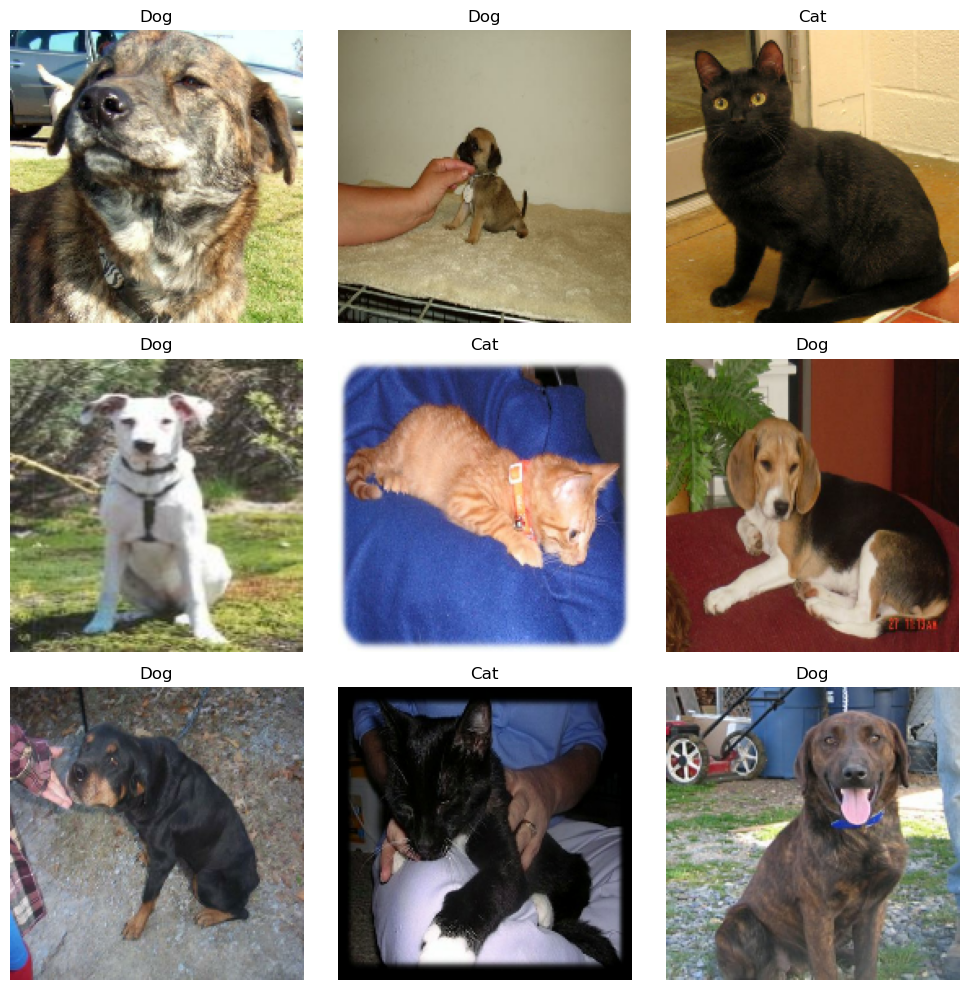

In [32]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Otimizando o carregamento dos dados

- `cache()` mantém os dados em cache após o primeiro carregamento;
- `shuffle()` embaralha as imagens de treino;
- `prefetch()` prepara o próximo lote enquanto o modelo está treinando.

In [33]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=seed).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 9. Criando um modelo simples

Este modelo é simples e serve para demonstrar o fluxo geral.

Ele faz:

1. normalização dos pixels de 0–255 para 0–1;
2. transformação da imagem em um vetor com `Flatten`;
3. classificação usando camadas densas.

Na próxima aula, substituiremos esta abordagem por uma CNN.

In [34]:
#model = keras.Sequential([
#    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
#    layers.Flatten(),
#    layers.Dense(128, activation="relu"),
#    layers.Dense(num_classes)
#])

#model.summary()

In [35]:
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes)
])

## 10. Compilando o modelo

Como os rótulos são inteiros (`0`, `1`, `2`, ...), usamos `SparseCategoricalCrossentropy`.

O parâmetro `from_logits=True` é usado porque a última camada retorna pontuações brutas, não probabilidades.

In [36]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

## 11. Treinando o modelo

Observe principalmente:

- `accuracy`: acurácia no treino;
- `val_accuracy`: acurácia na validação;
- `loss`: erro no treino;
- `val_loss`: erro na validação.

In [37]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 342ms/step - accuracy: 0.6520 - loss: 0.6122 - val_accuracy: 0.7221 - val_loss: 0.5322
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 267s 428ms/step - accuracy: 0.7560 - loss: 0.4992 - val_accuracy: 0.7737 - val_loss: 0.4654
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 274s 438ms/step - accuracy: 0.8023 - loss: 0.4277 - val_accuracy: 0.8021 - val_loss: 0.4302
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 348s 557ms/step - accuracy: 0.8476 - loss: 0.3466 - val_accuracy: 0.8043 - val_loss: 0.4306
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 429s 687ms/step - accuracy: 0.8964 - loss: 0.2476 - val_accuracy: 0.8157 - val_loss: 0.4488


## 12. Visualizando acurácia e erro

Esses gráficos ajudam a identificar se o modelo está aprendendo e se há indícios de *overfitting*.

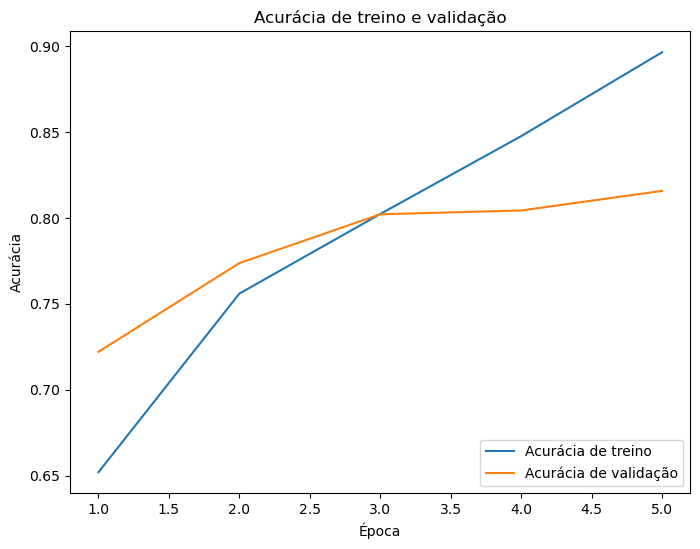

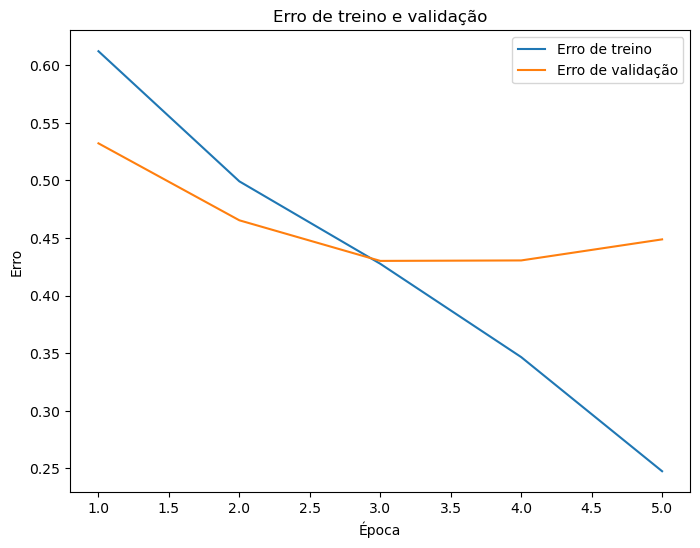

In [46]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 6))
plt.plot(epochs_range, acc, label="Acurácia de treino")
plt.plot(epochs_range, val_acc, label="Acurácia de validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend(loc="lower right")
plt.title("Acurácia de treino e validação")
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(epochs_range, loss, label="Erro de treino")
plt.plot(epochs_range, val_loss, label="Erro de validação")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend(loc="upper right")
plt.title("Erro de treino e validação")
plt.show()

## 13. Avaliação final no conjunto de validação

In [47]:
val_loss, val_accuracy = model.evaluate(val_ds)

print(f"Erro de validação: {val_loss:.4f}")
print(f"Acurácia de validação: {val_accuracy:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8157 - loss: 0.4488
Erro de validação: 0.4488
Acurácia de validação: 0.8157


## 14. Função para predizer uma imagem nova

Coloque uma imagem de teste no mesmo diretório do notebook ou informe o caminho completo no parâmetro `img_path`.

Exemplo:

```python
predict_image("teste.jpg")
```

In [48]:
def predict_image(img_path):
    img_path = Path(img_path)

    if not img_path.exists():
        raise FileNotFoundError(f"Imagem não encontrada: {img_path.resolve()}")

    img = tf.keras.utils.load_img(
        img_path,
        target_size=(img_height, img_width)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)



    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    predicted_class = class_names[int(np.argmax(score))]
    confidence = 100 * float(np.max(score))

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predição: {predicted_class} ({confidence:.2f}%)")
    plt.show()

    print(f"Esta imagem parece ser '{predicted_class}' com {confidence:.2f}% de confiança.")

    print("\nProbabilidades por classe:")
    for class_name, prob in zip(class_names, score.numpy()):
        print(f"- {class_name}: {100 * prob:.2f}%")

    
    print("class_names:", class_names)
    print("predictions:", predictions[0])
    print("softmax:", score.numpy())
    print("argmax:", np.argmax(score))
    print("classe:", class_names[int(np.argmax(score))])

## 15. Testando uma imagem externa

Altere o caminho abaixo para uma imagem existente.

Por padrão, a célula está comentada para evitar erro caso `teste.jpg` ainda não exista.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


c:\Users\hjmou\miniconda3\envs\aula\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


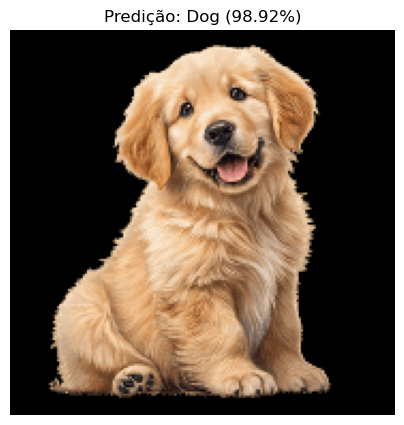

Esta imagem parece ser 'Dog' com 98.92% de confiança.

Probabilidades por classe:
- Cat: 1.08%
- Dog: 98.92%
class_names: ['Cat', 'Dog']
predictions: [-1.1770478  3.3434057]
softmax: [0.0107669  0.98923314]
argmax: 1
classe: Dog


In [54]:
predict_image("teste.png")

In [55]:
## 16. Exibindo a matriz de confusão

In [56]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    logits = model.predict(images, verbose=0)
    probs = tf.nn.softmax(logits).numpy()
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

print("Matriz de confusão:")
print(cm)

print("\nRelatório:")
print(classification_report(y_true, y_pred, target_names=class_names))

Matriz de confusão:
[[1968  474]
 [ 447 2109]]

Relatório:
              precision    recall  f1-score   support

         Cat       0.81      0.81      0.81      2442
         Dog       0.82      0.83      0.82      2556

    accuracy                           0.82      4998
   macro avg       0.82      0.82      0.82      4998
weighted avg       0.82      0.82      0.82      4998



## 17. Salvando o modelo treinado

Salvar o modelo permite reutilizá-lo depois sem treinar novamente.

In [57]:
model.save("modelo_classificacao_imagens_aula1.keras")
print("Modelo salvo em: modelo_classificacao_imagens_aula1.keras")

Modelo salvo em: modelo_classificacao_imagens_aula1.keras
